In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. Carga de Librerías y Data

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Cargar tu panel
panel_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/panel_data_final.csv')

panel_df['Date'] = pd.to_datetime(panel_df['Date'])

2. Análisis Detallado (JPM)

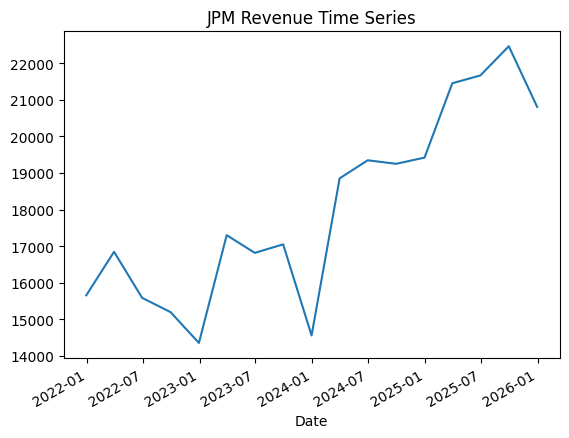

In [25]:
# =========================
# FILTRAR JPM
# =========================
jpm = panel_df[panel_df['Ticker'] == 'JPM'].copy()
jpm = jpm.sort_values('Date')

series = jpm.set_index('Date')['Revenue']

# =========================
# GRAFICA HISTÓRICA
# =========================
plt.figure()
series.plot(title='JPM Revenue Time Series')
plt.show()

3. Modelo ARIMA

In [26]:
model = ARIMA(series, order=(1,1,1))
results = model.fit()

print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                Revenue   No. Observations:                   17
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -141.515
Date:                Fri, 20 Mar 2026   AIC                            289.031
Time:                        01:45:01   BIC                            291.349
Sample:                             0   HQIC                           289.150
                                 - 17                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4859      3.906      0.124      0.901      -7.169       8.141
ma.L1         -0.5221      3.866     -0.135      0.893      -8.100       7.056
sigma2      3.017e+06   1.32e+06      2.285      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


4. Forecast JPM

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


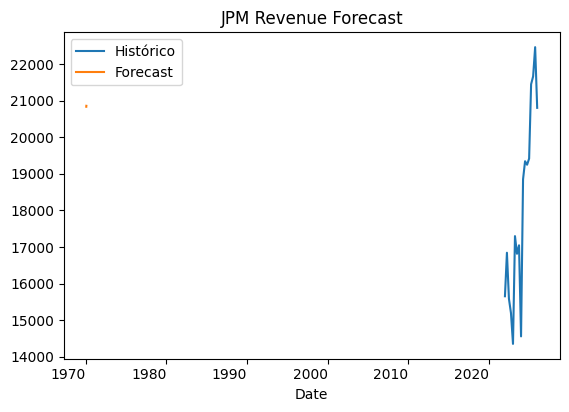

Forecast JPM:
17    20833.461238
18    20848.263324
19    20855.456128
20    20858.951341
Name: predicted_mean, dtype: float64


In [27]:
forecast_jpm = results.forecast(steps=4)

plt.figure()
series.plot(label='Histórico')
forecast_jpm.plot(label='Forecast')

plt.legend()
plt.title('JPM Revenue Forecast')
plt.show()

print("Forecast JPM:")
print(forecast_jpm)

5. Forecast para todas las empresas

In [28]:
forecast_dict = {}

for ticker in panel_df['Ticker'].unique():

    df_temp = panel_df[panel_df['Ticker'] == ticker].copy()
    df_temp = df_temp.sort_values('Date')

    series = df_temp.set_index('Date')['Revenue']

    try:
        model = ARIMA(series, order=(1,1,1))
        results = model.fit()

        forecast = results.forecast(steps=4)

        forecast_dict[ticker] = forecast.values

        print(f"✅ {ticker}")

    except:
        print(f"❌ Error en {ticker}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

✅ BAC
✅ CITI
✅ JPM
❌ Error en LRCX
✅ MS
✅ NVDA


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/

✅ RVIN
✅ SAN
✅ SHEL
✅ TSM
✅ VLO
✅ WFC
✅ XOM


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/

6. Tabla Final Forecast

In [29]:
forecast_df = pd.DataFrame(forecast_dict)

forecast_df.index = ['t+1', 't+2', 't+3', 't+4']

forecast_df

,BAC,CITI,JPM,MS,NVDA,RVIN,SAN,SHEL,TSM,VLO,WFC,XOM
t+1,10511.628061,5171.404472,20833.461238,7332.595295,77802.449988,1376.844211,3920.902552,64673.968699,34766.800173,23067.952867,8017.657370,79793.610298
t+2,10577.266113,5361.138930,20848.263324,7347.731169,86102.273660,1350.365296,4096.160602,64208.410889,35821.349453,22782.518508,7804.807420,79683.061491
t+3,10602.664941,5379.992539,20855.456128,7349.713038,93222.053419,1358.083266,3989.914821,64581.484472,36875.887840,22643.021593,7700.017612,79633.258918
t+4,10612.493089,5381.865992,20858.951341,7349.972541,99329.564353,1355.833662,4054.323651,64282.522892,37930.415335,22574.846937,7648.427729,79610.822708


7. Guardar Resultados

In [30]:
output_path = '/content/drive/MyDrive/Colab Notebooks/forecast_results.csv'

forecast_df.to_csv(output_path)

print("Archivo guardado en:", output_path)

Archivo guardado en: /content/drive/MyDrive/Colab Notebooks/forecast_results.csv


8. Tabla Interactiva

In [31]:
import ipywidgets as widgets
from IPython.display import display
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

def forecast_plot(ticker, variable):

    df_temp = panel_df[panel_df['Ticker'] == ticker].copy()
    df_temp = df_temp.sort_values('Date')

    series = df_temp.set_index('Date')[variable]

    model = ARIMA(series, order=(1,1,1))
    results = model.fit()

    forecast = results.forecast(steps=4)

    plt.figure()
    series.plot(label='Histórico')
    forecast.plot(label='Forecast')

    plt.title(f'{ticker} - {variable} Forecast')
    plt.legend()
    plt.show()

    display(forecast.to_frame(name='Forecast'))

widgets.interactive(
    forecast_plot,
    ticker=widgets.Dropdown(options=panel_df['Ticker'].unique(), description='Empresa:'),
    variable=widgets.Dropdown(options=['Revenue', 'NetIncome'], description='Variable:')
)

interactive(children=(Dropdown(description='Empresa:', options=('BAC', 'CITI', 'JPM', 'LRCX', 'MS', 'NVDA', 'R…

# CÓDIGO GARCH + ARIMA 5MIN

CÓDIGO GARCH + ARIMA 5MIN

In [36]:
import pandas as pd
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/JPM5min030126_031526.xlsx')

# LIMPIAR NOMBRES
df.columns = [col.strip() for col in df.columns]

print("Columnas detectadas:", df.columns)

# =========================
# DETECTAR DATETIME
# =========================
if 'Date' in df.columns and 'Time' in df.columns:
    df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])

elif 'Datetime' in df.columns:
    df['Datetime'] = pd.to_datetime(df['Datetime'])

elif 'Timestamp' in df.columns:
    df['Datetime'] = pd.to_datetime(df['Timestamp'])

else:
    # fallback: usar primera columna
    df['Datetime'] = pd.to_datetime(df.iloc[:,0])

# Ordenar
df = df.sort_values('Datetime')

Columnas detectadas: Index(['Exchange Date', 'Exchange Time', 'Local Date', 'Local Time', 'Close',
       'Net', '%Chg', 'Open', 'Low', 'High', 'Volume'],
      dtype='object')


In [33]:
# =========================
# 1. LIBRERÍAS
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import ipywidgets as widgets
import glob
import os

# =========================
# 2. PATH ARCHIVOS 5MIN
# =========================
path = '/content/drive/MyDrive/Colab Notebooks/*.xlsx'
files = [f for f in glob.glob(path) if '5min' in f]

# Crear diccionario ticker -> archivo
file_dict = {}

for f in files:
    ticker = os.path.basename(f).split('5min')[0]
    file_dict[ticker] = f

print("Tickers disponibles:", list(file_dict.keys()))

# =========================
# 3. FUNCIONES
# =========================
def get_price_column(df):
    possible_cols = ['Close', 'Last', 'Price', 'Last Price']
    for col in possible_cols:
        if col in df.columns:
            return col
    return None

def run_forecast(ticker):

    file_path = file_dict[ticker]
    df = pd.read_excel(file_path)

    df.columns = [col.strip() for col in df.columns]

    # =========================
    # DATETIME
    # =========================
    if 'Date' in df.columns and 'Time' in df.columns:
        df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
    elif 'Datetime' in df.columns:
        df['Datetime'] = pd.to_datetime(df['Datetime'])
    else:
        df['Datetime'] = pd.to_datetime(df.iloc[:,0])

    df = df.sort_values('Datetime')

    # =========================
    # PRECIO
    # =========================
    price_col = get_price_column(df)

    if price_col is None:
        print("No se encontró columna de precio")
        return

    price = df[price_col]

    # =========================
    # RETURNS
    # =========================
    returns = np.log(price).diff().dropna()

    # =========================
    # MODELO
    # =========================
    model = ARIMA(returns, order=(1,0,1))
    results = model.fit()

    forecast = results.forecast(steps=20)

    # =========================
    # PLOT
    # =========================
    plt.figure()
    returns.plot(label='Returns')
    forecast.plot(label='Forecast')

    plt.title(f'{ticker} - 5min Forecast')
    plt.legend()
    plt.show()

    print("Forecast:")
    print(forecast)

# =========================
# 4. DROPDOWN INTERACTIVO
# =========================
widgets.interactive(
    run_forecast,
    ticker=widgets.Dropdown(options=list(file_dict.keys()), description='Ticker:')
)

Tickers disponibles: ['JPM', 'AMAT', 'BAC', 'CITI', 'LRCX', 'MS', 'NVDA', 'RIVN', 'SAN', 'SHEL', 'STLA', 'TSM', 'VLO', 'WFC', 'XOM']


interactive(children=(Dropdown(description='Ticker:', options=('JPM', 'AMAT', 'BAC', 'CITI', 'LRCX', 'MS', 'NV…